In [2]:
import yfinance as yf  # This library is used to download data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# 1. DOWNLOAD STOCK DATA
ticker = "AAPL" # Apple stock data
data = yf.download(ticker, start="2022-01-01", end="2025-01-01")
data


[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2022-01-03,177.939743,178.790298,173.735915,173.853227,104487900
2022-01-04,175.681381,178.848931,175.114350,178.545866,99310400
2022-01-05,171.008286,176.140880,170.734548,175.593406,94537600
2022-01-06,168.153595,171.379801,167.801645,168.837938,96904000
2022-01-07,168.319733,170.245678,167.205227,169.023632,86709100
...,...,...,...,...,...
2024-12-24,256.560822,256.570737,253.669277,253.868019,23234700
2024-12-26,257.375580,258.448740,255.994420,256.550862,27237100


In [10]:
# 2. CREATE MOVING AVERAGES
data["MA50"] = data["Close"].rolling(window=50).mean() # Calculate 50-day moving average - Short term trend
data["MA200"] = data["Close"].rolling(window=200).mean() # Calculate 200-day moving average - Long term trend
print(data[["Close", "MA50", "MA200"]])

Price            Close MA50 MA200
Ticker            AAPL           
Date                             
2022-01-03  177.939743  NaN   NaN
2022-01-04  175.681381  NaN   NaN
2022-01-05  171.008286  NaN   NaN
2022-01-06  168.153595  NaN   NaN
2022-01-07  168.319733  NaN   NaN
...                ...  ...   ...
2024-12-24  256.560822  NaN   NaN
2024-12-26  257.375580  NaN   NaN
2024-12-27  253.967377  NaN   NaN
2024-12-30  250.598892  NaN   NaN
2024-12-31  248.830200  NaN   NaN

[753 rows x 3 columns]


In [12]:
# 3. GENERATE TREND SIGNALS
data["Signal"] = 0
# Buy signal
data.loc[data["MA50"] > data["MA200"], "Signal"] = 1   # Recent prices stronger than long-term prices - Bullish signal/Upward momentum - Buy
# Sell signal
data.loc[data["MA50"] < data["MA200"], "Signal"] = -1   # Recent prices weaker than long-term prices - Bearish signal/Downward momentum - Sell


In [13]:

# 4. CALCULATE RETURNS

data["Market_Return"] = data["Close"].pct_change() # Calculate daily returns of the stock, EX: If yesterday's price was $100 and today's price is $110, the return is (110-100)/100 = 0.10 or 10%

# Strategy return
data["Strategy_Return"] = (    # Calculate strategy returns by multiplying market returns with the signal from the previous day (shifted by 1), Shift means Use yesterday’s signal for today’s trade
    data["Market_Return"] * data["Signal"].shift(1)
)

# Remove NaN
data.dropna(inplace=True)


In [ ]:
# 5. CUMULATIVE RETURNS
# Calculate total strategy growth over time by compounding the returns, 
# EX: If you start with $100 and have a return of 10% in the first period, your new total is $110. If you then have a return of 5% in the next period, your new total is $110 * (1 + 0.05) = $115.50
data["Cumulative_Market"] = (
    1 + data["Market_Return"]
).cumprod()

data["Cumulative_Strategy"] = (
    1 + data["Strategy_Return"]
).cumprod()


In [ ]:
# 6. PERFORMANCE METRICS

# Total Return
total_return = (  # Calculate total return by taking the final value of the cumulative strategy and subtracting 1 (to get the percentage growth), then multiplying by 100 to convert to percentage.
    data["Cumulative_Strategy"].iloc[-1] - 1
) * 100

# CAGR
days = (data.index[-1] - data.index[0]).days # Calculate total trading days. 

years = days / 365

cagr = (     # Annual growth rate.
    (data["Cumulative_Strategy"].iloc[-1]) ** (1 / years) - 1
) * 100

# Sharpe Ratio
risk_free_rate = 0

    # Sharpe Ratio	Meaning
    # > 1	Good
    # > 2	Very good
    # < 0	Bad

sharpe_ratio = (   # Return per unit risk. 
    (
        data["Strategy_Return"].mean() - risk_free_rate
    ) / data["Strategy_Return"].std()
) * np.sqrt(252)

# Sortino Ratio: Selects only: losing returns
negative_returns = data["Strategy_Return"][
    data["Strategy_Return"] < 0
]

sortino_ratio = (  # Downside risk efficiency, Better than Sharpe for many traders.
    data["Strategy_Return"].mean()
    / negative_returns.std()
) * np.sqrt(252)

# Drawdown: Track highest portfolio value reached.
rolling_max = data["Cumulative_Strategy"].cummax()

drawdown = ( # Calculates: fall from peak
    data["Cumulative_Strategy"] - rolling_max
) / rolling_max

max_drawdown = drawdown.min() * 100

# Volatility: Measures: market randomness/risk Higher volatility: higher risk
volatility = (
    data["Strategy_Return"].std()
) * np.sqrt(252) * 100


In [ ]:
# 7. WIN RATE
winning_trades = data[data["Strategy_Return"] > 0] # Stores profitable trades.
losing_trades = data[data["Strategy_Return"] < 0] # Stores losing trades.

win_rate = ( # Calculates: percentage of winning trades
    len(winning_trades)
    / (len(winning_trades) + len(losing_trades))
) * 100

# Average Win
avg_win = winning_trades["Strategy_Return"].mean() * 100

# Average Loss
avg_loss = losing_trades["Strategy_Return"].mean() * 100

# Win/Loss Ratio: Measures: reward vs risk
win_loss_ratio = abs(avg_win / avg_loss)


In [ ]:
# 8. ACCURACY & PRECISION
accuracy = win_rate
precision = ( # Measures: how many buy signals were profitable
    len(winning_trades)
    / len(data[data["Signal"] == 1])
) * 100


In [12]:
# 9. AVERAGE HOLDING PERIOD

data["Trade_Change"] = data["Signal"].diff()

trade_points = data[data["Trade_Change"] != 0].index

holding_periods = []

for i in range(1, len(trade_points)):
    diff = (
        trade_points[i] - trade_points[i - 1]
    ).days

    holding_periods.append(diff)

if len(holding_periods) > 0:
    avg_holding_period = np.mean(holding_periods)
else:
    avg_holding_period = 0


In [13]:

# 10. DISPLAY METRICS

print("\n")
print("=" * 50)
print("TREND FOLLOWING STRATEGY RESULTS")
print("=" * 50)

print(f"\nTotal Return: {total_return:.2f}%")
print(f"CAGR: {cagr:.2f}%")
print(f"Sharpe Ratio: {sharpe_ratio:.2f}")
print(f"Sortino Ratio: {sortino_ratio:.2f}")
print(f"Max Drawdown: {max_drawdown:.2f}%")
print(f"Volatility: {volatility:.2f}%")

print("\n------ TRADE METRICS ------")

print(f"Win Rate: {win_rate:.2f}%")
print(f"Win/Loss Ratio: {win_loss_ratio:.2f}")
print(f"Average Win: {avg_win:.2f}%")
print(f"Average Loss: {avg_loss:.2f}%")

print("\n------ ML STYLE METRICS ------")

print(f"Accuracy: {accuracy:.2f}%")
print(f"Precision: {precision:.2f}%")
print(f"Average Holding Period: {avg_holding_period:.2f} days")




TREND FOLLOWING STRATEGY RESULTS

Total Return: -11.73%
CAGR: -5.50%
Sharpe Ratio: -0.11
Sortino Ratio: -0.14
Max Drawdown: -34.21%
Volatility: 24.05%

------ TRADE METRICS ------
Win Rate: 51.36%
Win/Loss Ratio: 0.93
Average Win: 1.06%
Average Loss: -1.14%

------ ML STYLE METRICS ------
Accuracy: 51.36%
Precision: 73.51%
Average Holding Period: 201.33 days


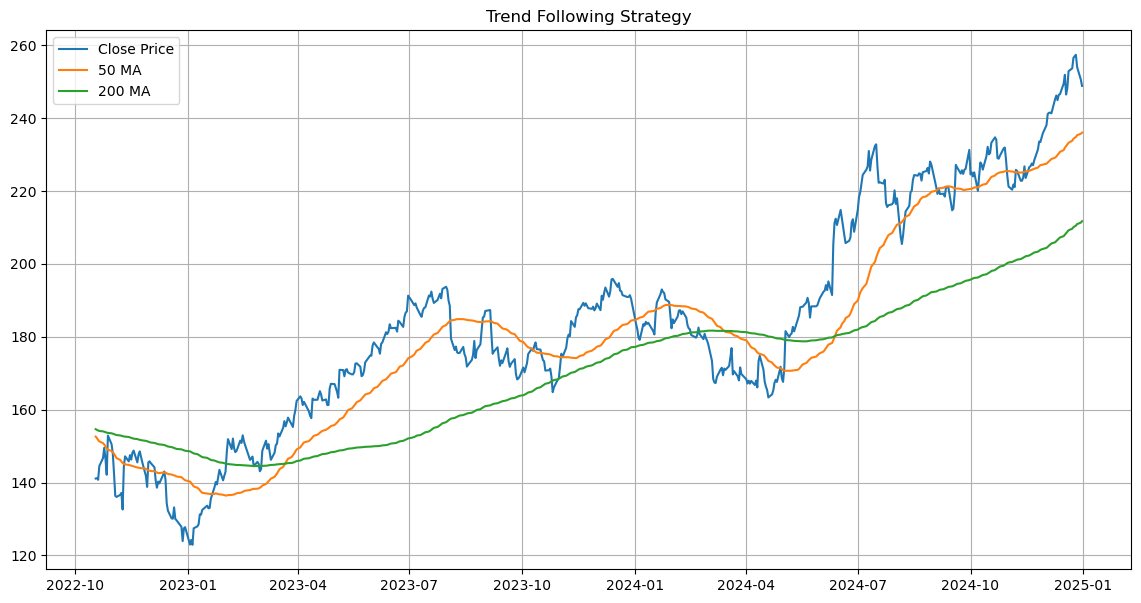

In [14]:
# 11. PLOT RESULTS


plt.figure(figsize=(14, 7))

plt.plot(
    data.index,
    data["Close"],
    label="Close Price"
)

plt.plot(
    data.index,
    data["MA50"],
    label="50 MA"
)

plt.plot(
    data.index,
    data["MA200"],
    label="200 MA"
)


plt.title("Trend Following Strategy")

plt.legend()

plt.grid(True)

plt.show()


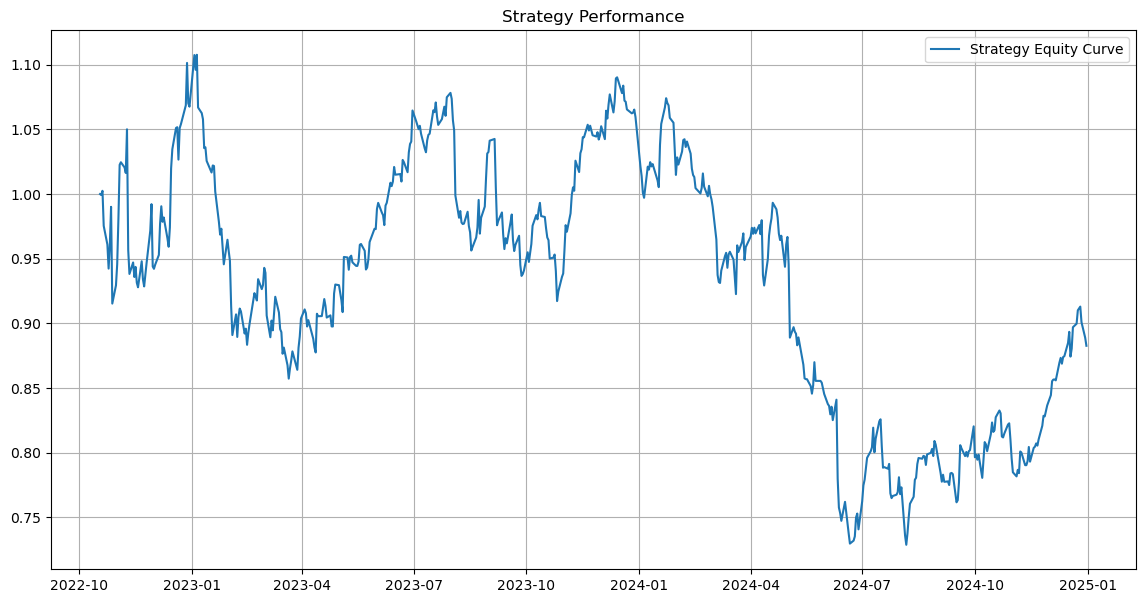

In [15]:
# 12. EQUITY CURVE

plt.figure(figsize=(14, 7))

plt.plot(
    data.index,
    data["Cumulative_Strategy"],
    label="Strategy Equity Curve"
)

plt.title("Strategy Performance")

plt.legend()

plt.grid(True)

plt.show()